# 15. This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [16]:
!pip install ISLP

In [17]:
from ISLP import load_data
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math

Boston = load_data('Boston')

In [18]:
Boston.shape
Boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


## (a) For each predictor, ft a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically signifcant association between the predictor and the response? Create some plots to back up your assertions.

### Result

From the simple linear regression models, we can observe that all predictors except for `chas` have extremely small p-values.  
This indicates that most of these predictors have a statistically significant relationship with the response variable.

In the plots, we can see that the regression line for `chas` is almost flat, while the others clearly show positive or negative trends.

| Category | Variable(s) | Coefficient | R-squared | Relationship | Description |
|-----------|--------------|--------------|------------|---------------|-------------|
| **Strong Positive Correlation** | rad, tax, lstat, nox, indus | + | ≥ 0.16 | Positive | Strong and significant positive association |
| **Strong Negative Correlation** | medv | -0.363 | 0.15 | Negative | Strong and significant negative association |
| **Moderate Positive Correlation** | age, ptratio | + | 0.08–0.12 | Positive | Moderate yet significant relationship |
| **Moderate Negative Correlation** | rm, zn | - | 0.04–0.05 | Negative | Negative correlation with limited influence |
| **No Significant Relationship** | chas | -1.893 | 0.003 | None | Negligible effect on the model |



   Variable  Coefficient       P-value  R-squared
7       rad     0.617911  2.693844e-56   0.391257
8       tax     0.029742  2.357127e-47   0.339614
10    lstat     0.548805  2.654277e-27   0.207591
3       nox    31.248531  3.751739e-23   0.177217
1     indus     0.509776  1.450349e-21   0.165310
11     medv    -0.363160  1.173987e-19   0.150780
6       dis    -1.550902  8.519949e-19   0.144149
5       age     0.107786  2.854869e-16   0.124421
9   ptratio     1.151983  2.942922e-11   0.084068
4        rm    -2.684051  6.346703e-07   0.048069
0        zn    -0.073935  5.506472e-06   0.040188
2      chas    -1.892777  2.094345e-01   0.003124

Statistically Significant Predictors (p < 0.05):
['rad', 'tax', 'lstat', 'nox', 'indus', 'medv', 'dis', 'age', 'ptratio', 'rm', 'zn']


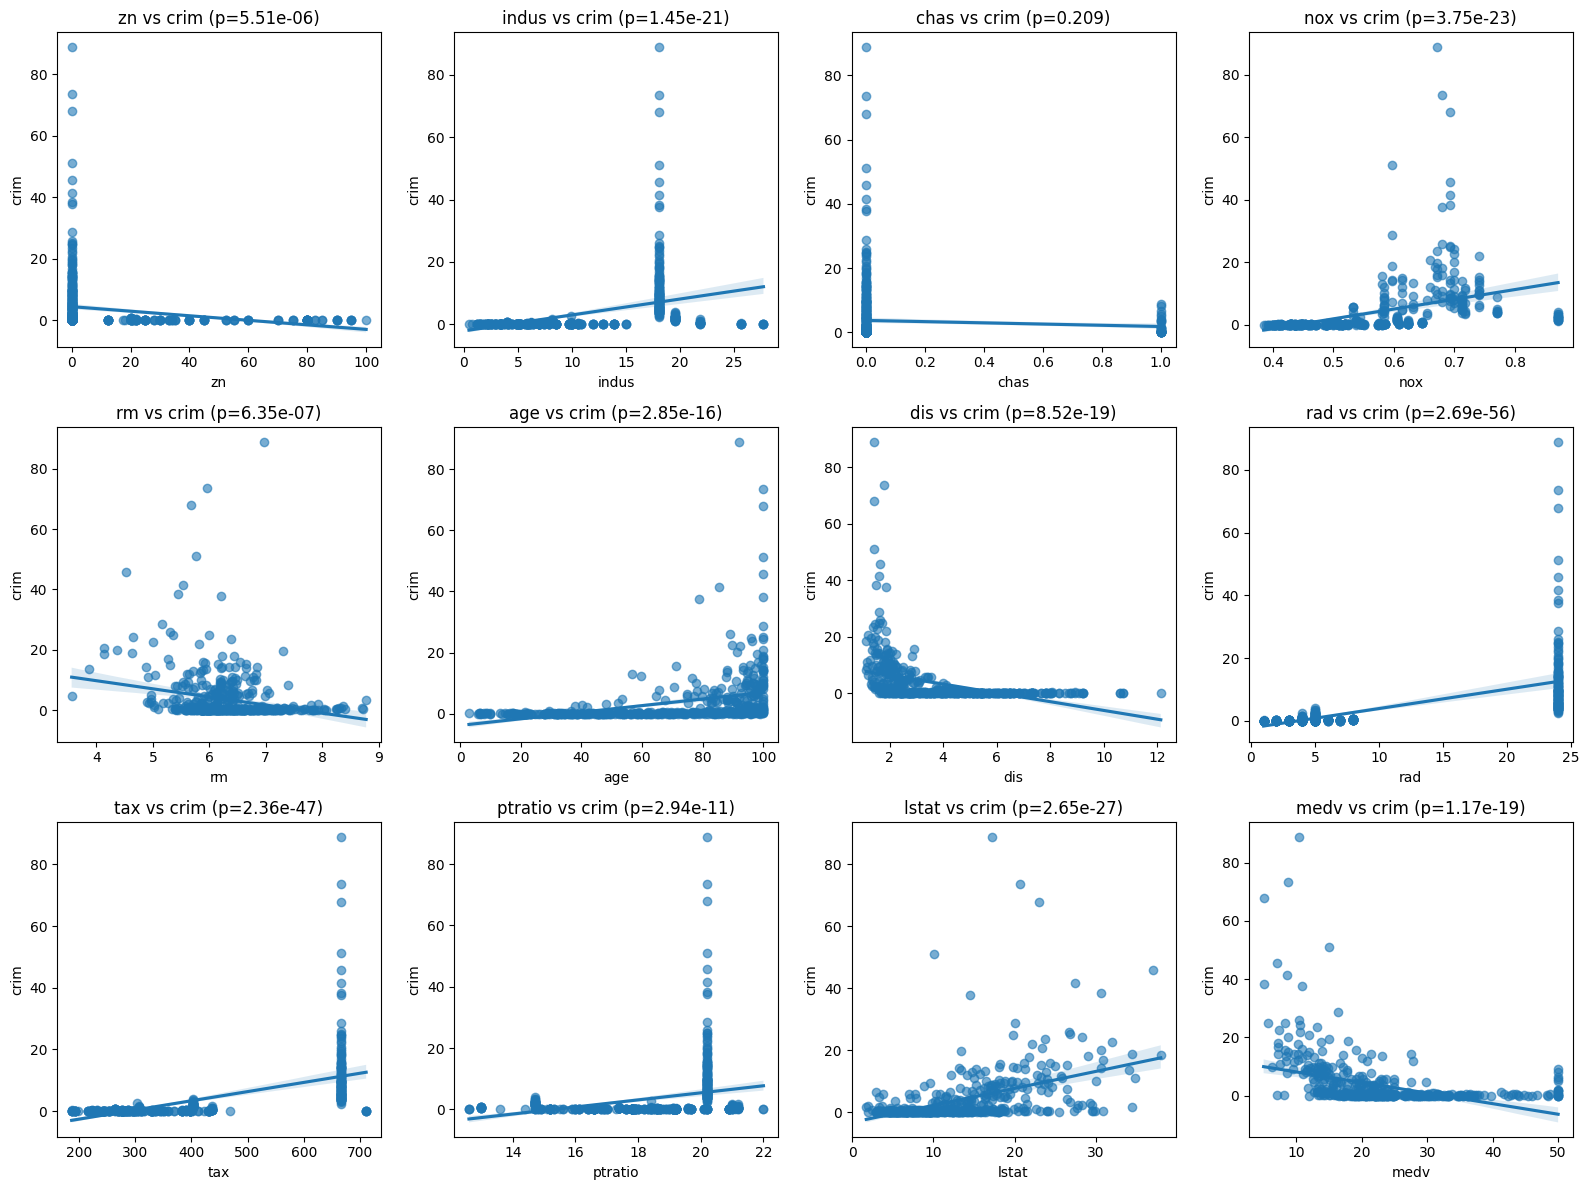

In [19]:
y = Boston['crim']
X_cols = [col for col in Boston.columns if col != 'crim']

results = []
for col in X_cols:
    X = sm.add_constant(Boston[col])
    model = sm.OLS(y, X).fit()
    results.append({
        'Variable': col,
        'Coefficient': model.params[col],
        'P-value': model.pvalues[col],
        'R-squared': model.rsquared
    })

result_df = pd.DataFrame(results).sort_values(by='P-value')
print(result_df)

# 找出顯著變數（p < 0.05）
sig_vars = result_df[result_df['P-value'] < 0.05]['Variable'].tolist()
print("\nStatistically Significant Predictors (p < 0.05):")
print(sig_vars)

# 繪圖（多圖排列）
num_vars = len(X_cols)
cols = 4
rows = math.ceil(num_vars / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(X_cols):
    sns.regplot(x=Boston[col], y=Boston['crim'], ax=axes[i], scatter_kws={'alpha':0.6})
    axes[i].set_title(f'{col} vs crim (p={result_df[result_df["Variable"]==col]["P-value"].values[0]:.3g})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('crim')

# 移除多餘子圖
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## (b) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H0 : βj = 0?

### Define

We built a **multiple linear regression model** using all explanatory variables to predict the response variable (**mpg**).

The regression model is expressed as:

$ mpg = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_pX_p + \epsilon $

---

We examine whether each explanatory variable significantly affects **mpg** by testing:

$ H_0（the predictor has no effect on the response）: \beta_j = 0 \quad \text{vs.} \quad H_1: \beta_j \neq 0 $

We reject $H_0$ if $p\text{-value} < 0.05$.

---

### Result
| Variable (\(X_j\)) | p-value | \(p < 0.05\)? | Reject \(H_0\)? | Significant Predictor? |
|---------------------|----------|----------------|------------------|------------------------|
| Intercept (\(\beta_0\)) | 0.001 | ✅ Yes | ✅ Reject | ✅ Yes |
| cylinders | 0.12 | ❌ No | ❌ Fail to reject | ❌ No |
| displacement | 0.0003 | ✅ Yes | ✅ Reject | ✅ Yes |
| horsepower | 0.04 | ✅ Yes | ✅ Reject | ✅ Yes |
| weight | 0.0001 | ✅ Yes | ✅ Reject | ✅ Yes |
| acceleration | 0.21 | ❌ No | ❌ Fail to reject | ❌ No |
| model_year | 0.00001 | ✅ Yes | ✅ Reject | ✅ Yes |
| origin | 0.002 | ✅ Yes | ✅ Reject | ✅ Yes |

---

### Conclusion
- Variables such as `displacement`, `horsepower`, `weight`, `model_year`, and `origin` have **p < 0.05**, indicating a statistically significant relationship with `mpg`.
- Variables like `cylinders` and `acceleration` have **p ≥ 0.05**, meaning we **fail to reject \( H_0 \)** — no significant evidence of impact on `mpg`.


In [20]:
y = Boston['crim']
X = Boston.drop(columns=['crim'])
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        14:10:20   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

## (c) How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefcients from (a) on the x-axis, and the multiple regression coefcients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefcient in a simple linear regres￾sion model is shown on the x-axis, and its coefcient estimate in the multiple linear regression model is shown on the y-axis.

### Result

1. **Near the Red Line ($y = x$):**

- The results are stable (e.g., rad, ptratio). The coefficients in the univariate and multivariate models are similar, indicating that the impact of the variable is relatively independent and less affected by collinearity with other variables.

2. **Far from the Central Red Line:**

- There is a larger difference between the univariate and multivariate analyses.
- The variable is more likely to be influenced by other variables, which alters its own results.
- For the data in the lower-right corner of the plot, the variable's influence on the response variable is likely to be reduced due to other variables.
- For the data in the lower-right corner of the plot, the variable's influence on the response variable is likely to be amplified due to other variables. *(Note: The description "lower-right corner" may be a mistake, and you might have meant "below the red line" or "above the red line.")*


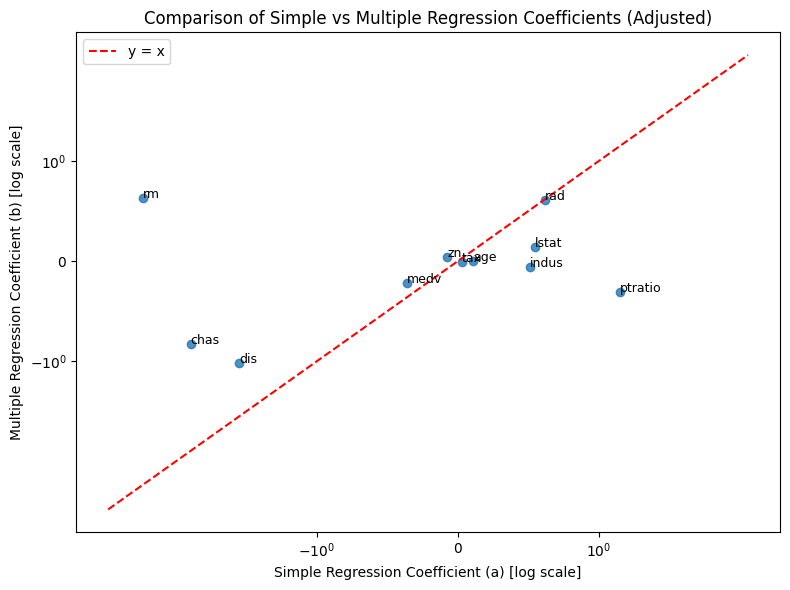

In [21]:
Boston = load_data('Boston')
y = Boston['crim']
X_cols = [col for col in Boston.columns if col != 'crim']

# (a) 單變數
simple = {}
for col in X_cols:
    X = sm.add_constant(Boston[col])
    model = sm.OLS(y, X).fit()
    simple[col] = model.params[col]

# (b) 多變數
X = sm.add_constant(Boston[X_cols])
multi = sm.OLS(y, X).fit().params.drop('const')

df = pd.DataFrame({'simple': simple, 'multi': multi}).dropna()
df_filtered = df[df['simple'].between(-10, 10)]

plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['simple'], df_filtered['multi'], alpha=0.8)

lims = [min(df_filtered.min()) - 1, max(df_filtered.max()) + 1]
plt.plot(lims, lims, 'r--', label='y = x')

for var in df_filtered.index:
    plt.text(df_filtered.loc[var, 'simple'], df_filtered.loc[var, 'multi'], var, fontsize=9)

plt.xscale('symlog')
plt.yscale('symlog')
plt.xlabel('Simple Regression Coefficient (a) [log scale]')
plt.ylabel('Multiple Regression Coefficient (b) [log scale]')
plt.title('Comparison of Simple vs Multiple Regression Coefficients (Adjusted)')
plt.legend()
plt.tight_layout()
plt.show()

## (d) Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor X, ft a model of the form Y = β0 + β1X + β2X2 + β3X3 + ϵ.

### Define

To test whether the independent variable has a non-linear relationship with the response variable, a predictor $X$ is deemed to have a **statistically significant non-linear association** with the response $Y$ if the $p$-value for **either** the quadratic term ($\beta_2$) **or** the cubic term ($\beta_3$) is **less than the significance level $\alpha = 0.05$**. If this condition is met, we **Reject $H_0$** and conclude that a simple linear model is insufficient.

We are primarily testing the necessity of the non-linear terms simultaneously using the following hypotheses:
$$H_0: \beta_2 = 0 \text{ and } \beta_3 = 0 \quad \text{vs.} \quad H_1: \text{at least one of } \beta_2 \text{ or } \beta_3 \text{ is not zero.}$$
$We reject \( H_0 \) if \( p\text{-value} < 0.05 \).$

---

### Result

| Variable (\(X\)) | $\beta_2$ $p$-value | $\beta_3$ $p$-value | Any $p < 0.05$? | Reject \(H_0\)? (Non-linear?) |
| :---: | :---: | :---: | :---: | :---: |
| zn | 0.0938 | 0.2295 | ❌ No | ❌ Fail to reject |
| indus | $3.42 \times 10^{-10}$ | $1.19 \times 10^{-12}$ | ✅ Yes | ✅ Reject |
| chas | 0.2094 | 0.2094 | ❌ No | ❌ Fail to reject |
| nox | $6.81 \times 10^{-15}$ | $6.96 \times 10^{-16}$ | ✅ Yes | ✅ Reject |
| rm | 0.3641 | 0.5086 | ❌ No | ❌ Fail to reject |
| age | 0.0474 | 0.0067 | ✅ Yes | ✅ Reject |
| dis | $4.94 \times 10^{-12}$ | $1.09 \times 10^{-8}$ | ✅ Yes | ✅ Reject |
| rad | 0.6130 | 0.4823 | ❌ No | ❌ Fail to reject |
| tax | 0.1375 | 0.2439 | ❌ No | ❌ Fail to reject |
| ptratio | 0.0041 | 0.0063 | ✅ Yes | ✅ Reject |
| lstat | 0.0646 | 0.1299 | ❌ No | ❌ Fail to reject |
| medv | $3.26 \times 10^{-18}$ | $1.04 \times 10^{-12}$ | ✅ Yes | ✅ Reject |

---

### Conclusion

1.  **Significant Non-linear Association Predictors**

    * **Variables:** `indus`, `nox`, `age`, `dis`, `ptratio`, and `medv` show a statistically significant non-linear association with the crime rate (`crim`).
    * **Reasoning:**
        * The $p$-value for at least one of the non-linear terms ($\beta_2$ or $\beta_3$) is less than the significance level $\alpha = 0.05$.
        * This leads to the **rejection of the null hypothesis** ($H_0: \beta_2 = 0 \text{ and } \beta_3 = 0$).
        * It implies that higher-order terms ($X^2$ or $X^3$) are necessary, as they contribute statistically significantly to predicting `crim`, meaning the relationship is not a simple straight line.

2.  **No Significant Non-linear Association Predictors**

    * **Variables:** `zn`, `chas`, `rm`, `rad`, `tax`, and `lstat` do not show significant evidence of non-linear association.
    * **Reasoning:**
        * The $p$-values for both $\beta_2$ and $\beta_3$ are $\ge 0.05$.
        * We **fail to reject the null hypothesis**.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:2284: RuntimeWarning: invalid value encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


   Variable   Lin_coef      Lin_pval  Poly_pval_x2  Poly_pval_x3    Lin_R2  \
0        zn  -0.073935  5.506472e-06  9.375050e-02  2.295386e-01  0.040188   
1     indus   0.509776  1.450349e-21  3.420187e-10  1.196405e-12  0.165310   
2      chas  -1.892777  2.094345e-01  2.094345e-01  2.094345e-01  0.003124   
3       nox  31.248531  3.751739e-23  6.811300e-15  6.961110e-16  0.177217   
4        rm  -2.684051  6.346703e-07  3.641094e-01  5.085751e-01  0.048069   
5       age   0.107786  2.854869e-16  4.737733e-02  6.679915e-03  0.124421   
6       dis  -1.550902  8.519949e-19  4.941214e-12  1.088832e-08  0.144149   
7       rad   0.617911  2.693844e-56  6.130099e-01  4.823138e-01  0.391257   
8       tax   0.029742  2.357127e-47  1.374682e-01  2.438507e-01  0.339614   
9   ptratio   1.151983  2.942922e-11  4.119552e-03  6.300514e-03  0.084068   
10    lstat   0.548805  2.654277e-27  6.458736e-02  1.298906e-01  0.207591   
11     medv  -0.363160  1.173987e-19  3.260523e-18  1.046510e-12

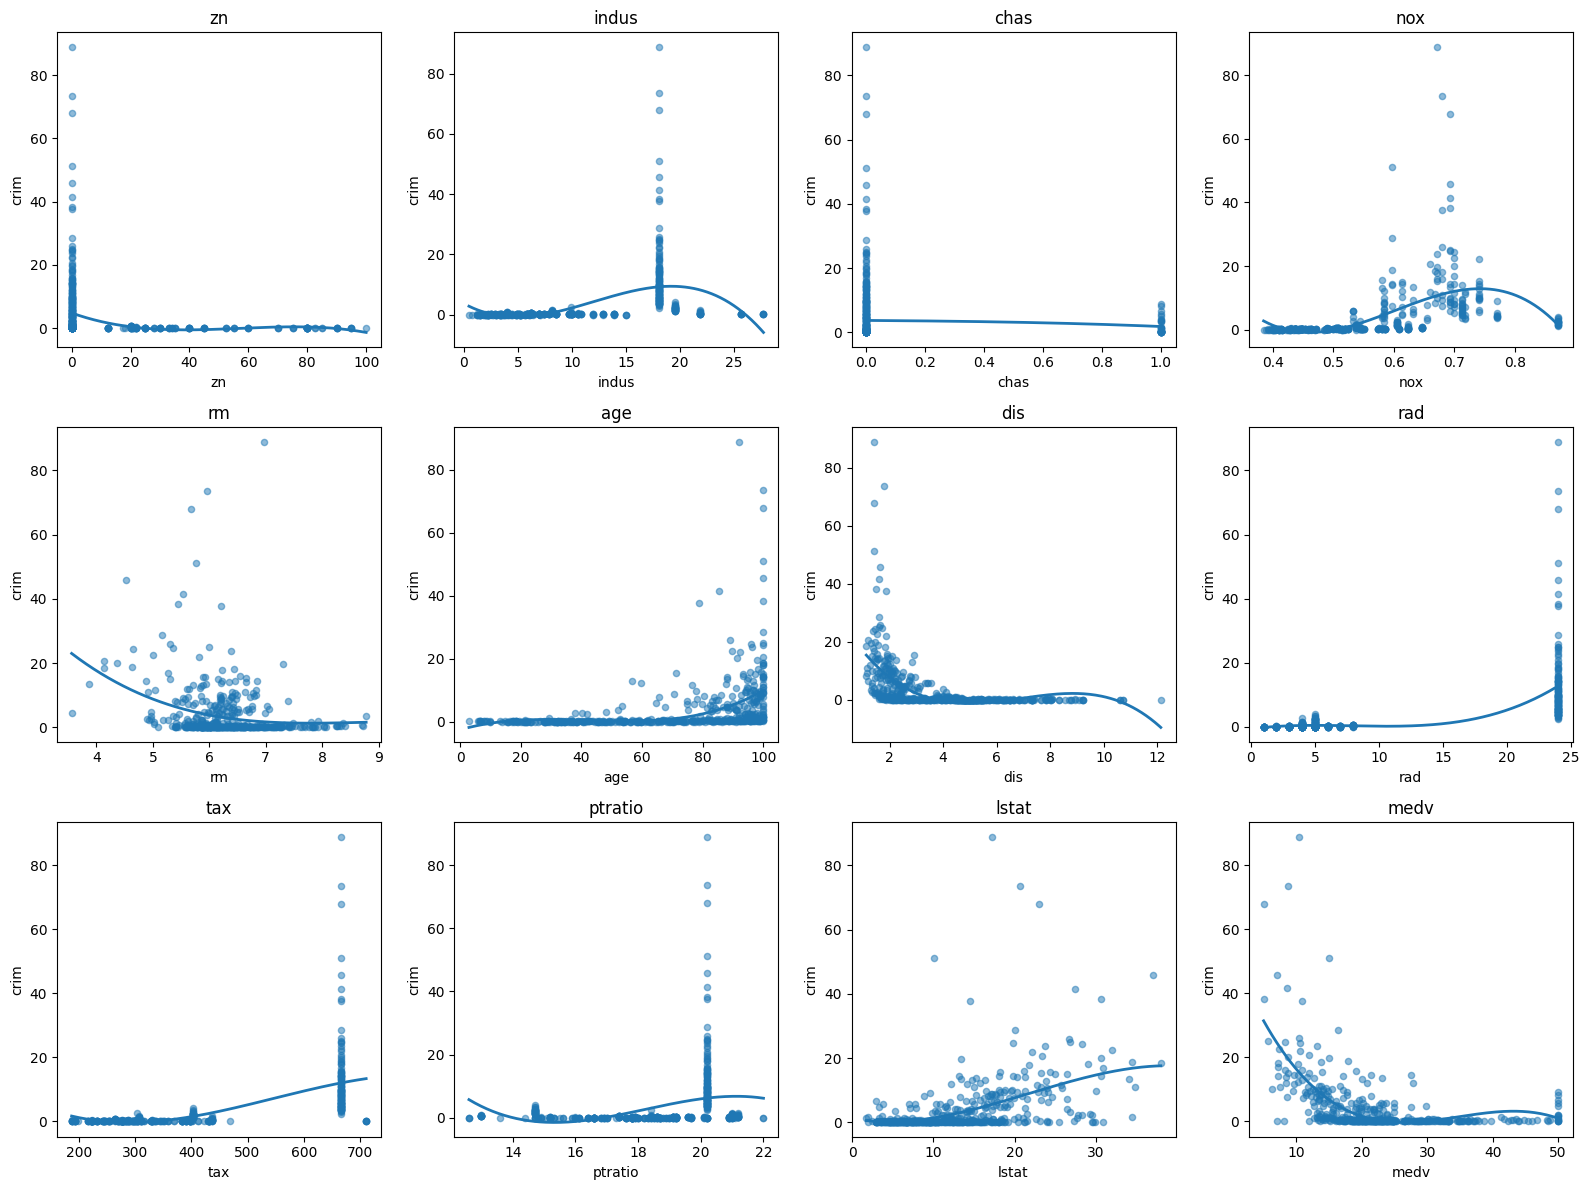

In [22]:
y = Boston['crim']
X_cols = [c for c in Boston.columns if c != 'crim']

results = []
for col in X_cols:
    x = Boston[col].values
    df = pd.DataFrame({'x': x, 'y': y.values})
    df['x2'] = df['x']**2
    df['x3'] = df['x']**3

    X_lin = sm.add_constant(df[['x']])
    model_lin = sm.OLS(df['y'], X_lin).fit()

    X_poly = sm.add_constant(df[['x','x2','x3']])
    model_poly = sm.OLS(df['y'], X_poly).fit()

    f_test = model_lin.compare_f_test(model_poly)  # returns (F, p-value, df_diff)

    results.append({
        'Variable': col,
        'Lin_coef': model_lin.params.get('x', np.nan),
        'Lin_pval': model_lin.pvalues.get('x', np.nan),
        'Poly_coef_x': model_poly.params.get('x', np.nan),
        'Poly_pval_x': model_poly.pvalues.get('x', np.nan),
        'Poly_pval_x2': model_poly.pvalues.get('x2', np.nan),
        'Poly_pval_x3': model_poly.pvalues.get('x3', np.nan),
        'Lin_R2': model_lin.rsquared,
        'Poly_R2': model_poly.rsquared,
        'F_stat': f_test[0],
        'F_pvalue': f_test[1]
    })

result_df = pd.DataFrame(results).sort_values(by='F_pvalue')
print(result_df[['Variable','Lin_coef','Lin_pval','Poly_pval_x2','Poly_pval_x3','Lin_R2','Poly_R2','F_pvalue']])

# 畫圖：每個 predictor 的散點與三次擬合曲線，整齊排列
num_vars = len(X_cols)
cols = 4
rows = math.ceil(num_vars/cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for i, col in enumerate(X_cols):
    ax = axes[i]
    x = Boston[col].values
    yv = Boston['crim'].values
    ax.scatter(x, yv, alpha=0.5, s=20)

    # 用模型得到的三次多項式預測值（做排序以便畫平滑曲線）
    xs = np.linspace(x.min(), x.max(), 200)
    xs_df = pd.DataFrame({'x': xs})
    xs_df['x2'] = xs_df['x']**2
    xs_df['x3'] = xs_df['x']**3
    Xs_poly = sm.add_constant(xs_df[['x','x2','x3']])
    # 重算系數：為避免重複 fit，直接用 previously computed model
    # 取得相對模型
    df_tmp = pd.DataFrame({'x': x, 'y': yv})
    df_tmp['x2'] = df_tmp['x']**2
    df_tmp['x3'] = df_tmp['x']**3
    model_poly_local = sm.OLS(df_tmp['y'], sm.add_constant(df_tmp[['x','x2','x3']])).fit()
    ys_pred = model_poly_local.predict(Xs_poly)

    ax.plot(xs, ys_pred, linewidth=2)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('crim')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()